# Quality KPI Dashboard

## Process Audit Decision

The objective is to identify the production plant where the next process audit should be conducted.

The decision is primarily based on:

- absolute defect frequency of vehicles in the field
- relative defect frequency of vehicles in the field

Only vehicle types Type11 and Type21 are considered.

A vehicle is considered defective if the vehicle itself, an installed component, or an installed individual part is marked as defective.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

In [2]:
FINAL_FOLDER = Path("data/final")

vehicle_quality = pd.read_csv(
    FINAL_FOLDER / "vehicle_quality.csv",
    parse_dates=[
        "Produktionsdatum",
        "Fehlerhaft_Datum",
        "Zulassungsdatum"
    ]
)

print(
    "Rows:",
    f"{len(vehicle_quality):,}"
)

print(
    "Columns:",
    len(vehicle_quality.columns)
)

print(
    "Unique vehicles:",
    vehicle_quality["ID_Fahrzeug"].is_unique
)

print(
    "Missing final defect status:",
    vehicle_quality["Fehlerhaft_Gesamt"].isna().sum()
)

Rows: 2,489,518
Columns: 48
Unique vehicles: True
Missing final defect status: 0


In [3]:
oem_kpi = (
    vehicle_quality
    .groupby(
        [
            "OEM",
            "Werksnummer_OEM",
            "ORT_OEM"
        ],
        as_index=False
    )
    .agg(
        Vehicles=(
            "ID_Fahrzeug",
            "size"
        ),
        Defective_Vehicles=(
            "Fehlerhaft_Gesamt",
            "sum"
        )
    )
)

oem_kpi["Defect_Rate"] = (
    oem_kpi["Defective_Vehicles"]
    / oem_kpi["Vehicles"]
)

oem_kpi["Defect_Rate_%"] = (
    oem_kpi["Defect_Rate"] * 100
)

oem_kpi = (
    oem_kpi
    .sort_values(
        "Defect_Rate",
        ascending=False
    )
    .reset_index(drop=True)
)

display(oem_kpi)

,OEM,Werksnummer_OEM,ORT_OEM,Vehicles,Defective_Vehicles,Defect_Rate,Defect_Rate_%
0,OEM2,21,GOETTINGEN,512354,455877,0.889770,88.976957
1,OEM1,11,NUERNBERG,1186298,1041102,0.877606,87.760580
2,OEM1,12,BONN,790866,693991,0.877508,87.750769


## KPI 1 — Absolute Defect Frequency

The absolute defect frequency shows how many defective vehicles produced by each plant are observed in the field.

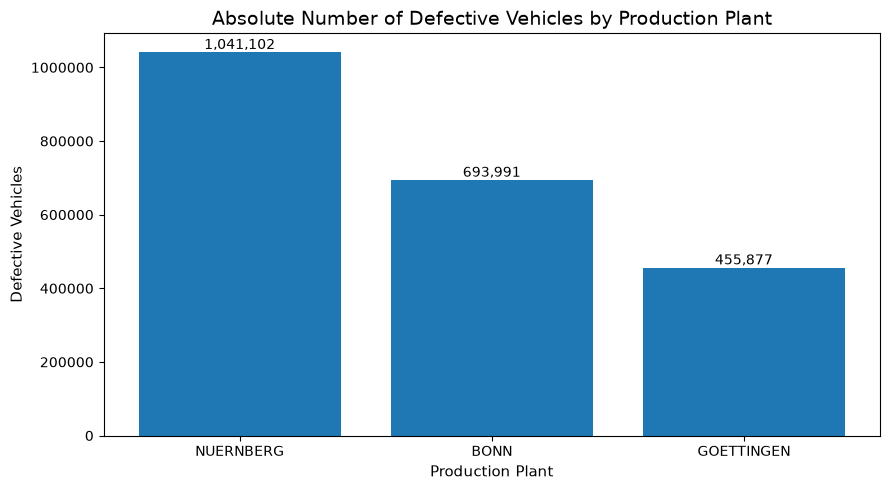

In [4]:
absolute_kpi = (
    oem_kpi
    .sort_values(
        "Defective_Vehicles",
        ascending=False
    )
)

fig, ax = plt.subplots()

bars = ax.bar(
    absolute_kpi["ORT_OEM"],
    absolute_kpi["Defective_Vehicles"]
)

ax.set_title(
    "Absolute Number of Defective Vehicles by Production Plant"
)

ax.set_xlabel(
    "Production Plant"
)

ax.set_ylabel(
    "Defective Vehicles"
)

ax.ticklabel_format(
    style="plain",
    axis="y"
)

for bar, value in zip(
    bars,
    absolute_kpi["Defective_Vehicles"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## KPI 2 — Relative Defect Frequency

The relative defect frequency accounts for differences in production volume and represents the share of defective vehicles produced by each plant.

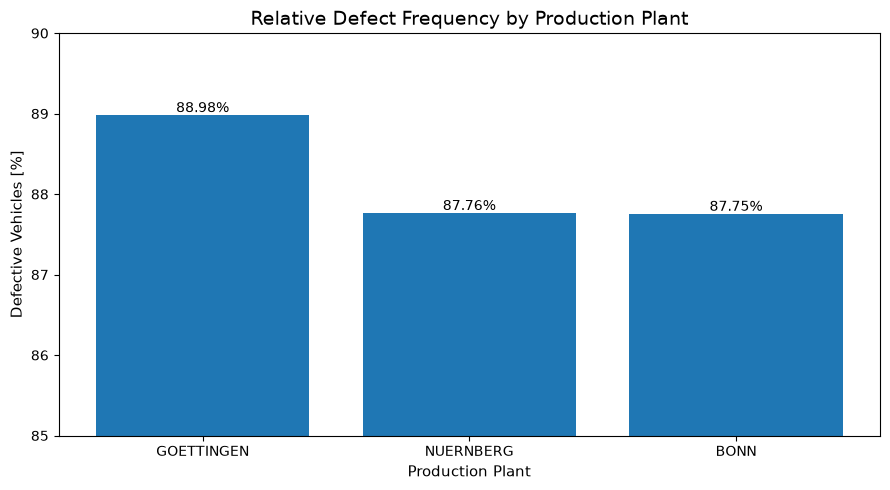

In [5]:
relative_kpi = (
    oem_kpi
    .sort_values(
        "Defect_Rate",
        ascending=False
    )
)

fig, ax = plt.subplots()

bars = ax.bar(
    relative_kpi["ORT_OEM"],
    relative_kpi["Defect_Rate_%"]
)

ax.set_title(
    "Relative Defect Frequency by Production Plant"
)

ax.set_xlabel(
    "Production Plant"
)

ax.set_ylabel(
    "Defective Vehicles [%]"
)

ax.set_ylim(
    85,
    90
)

for bar, value in zip(
    bars,
    relative_kpi["Defect_Rate_%"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## Audit Decision Overview

Absolute defect counts must be interpreted together with production volume. A high absolute number of defective vehicles can result from a large production volume, while the relative defect frequency indicates whether a plant performs disproportionately worse.

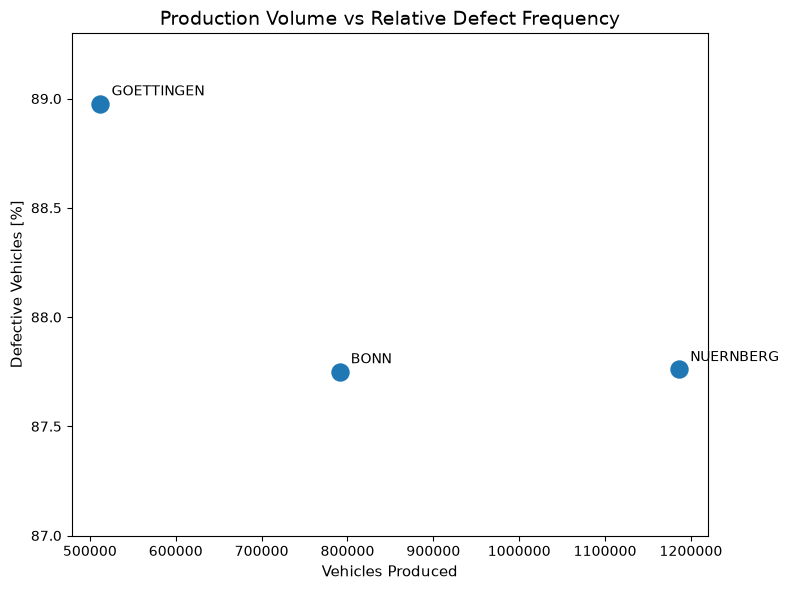

In [6]:
fig, ax = plt.subplots(
    figsize=(8, 6)
)

ax.scatter(
    oem_kpi["Vehicles"],
    oem_kpi["Defect_Rate_%"],
    s=150
)

for _, row in oem_kpi.iterrows():
    ax.annotate(
        row["ORT_OEM"],
        (
            row["Vehicles"],
            row["Defect_Rate_%"]
        ),
        xytext=(8, 6),
        textcoords="offset points"
    )

ax.set_title(
    "Production Volume vs Relative Defect Frequency"
)

ax.set_xlabel(
    "Vehicles Produced"
)

ax.set_ylabel(
    "Defective Vehicles [%]"
)

ax.set_ylim(
    87,
    89.3
)

ax.ticklabel_format(
    style="plain",
    axis="x"
)

plt.tight_layout()
plt.show()